# 🔍 Exploratory Data Analysis (EDA) — Tips Dataset
**Dataset:** `tips` from Seaborn built-in datasets  
**Goal:** Understand the data structure, distributions, and relationships between variables  
**Tools:** NumPy · Pandas · Matplotlib · Seaborn


## 1. Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 2. Load Dataset

In [2]:
# Load the tips dataset directly from seaborn's built-in datasets
tips = sns.load_dataset('tips')

## 3. First Look at the Data

In [3]:
# Display the first 5 rows to get a feel for the data structure
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [4]:
# Display the last 5 rows to confirm the data loaded correctly
tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


## 4. Data Structure & Info

In [5]:
# Number of rows and columns
print("Shape:", tips.shape)

Shape: (244, 7)


In [6]:
# List all column names
print("Columns:", tips.columns.tolist())

Columns: ['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size']


In [7]:
# Column data types and non-null counts
tips.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [8]:
# Detailed data type per column
tips.dtypes

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

## 5. Missing Values Check

In [9]:
# Check for missing values — tips dataset is clean, but this is a mandatory step in any EDA
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## 6. Descriptive Statistics

In [10]:
# Summary statistics for numerical columns (mean, std, min, max, quartiles)
tips.describe().T

,count,mean,std,min,25%,50%,75%,max
total_bill,244.0,19.785943,8.902412,3.07,13.3475,17.795,24.1275,50.81
tip,244.0,2.998279,1.383638,1.00,2.0000,2.900,3.5625,10.00
size,244.0,2.569672,0.951100,1.00,2.0000,2.000,3.0000,6.00


In [11]:
# Summary statistics for categorical columns
tips.describe(include=['object', 'category'])

,sex,smoker,day,time
count,244,244,244,244
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176


## 7. Categorical Column Exploration

In [12]:
# Unique values in the 'day' column and their count
print("Unique days:", tips['day'].unique())
print("Number of unique days:", tips['day'].nunique())

Unique days: ['Sun', 'Sat', 'Thur', 'Fri']
Categories (4, str): ['Thur', 'Fri', 'Sat', 'Sun']
Number of unique days: 4


In [13]:
# How many customers visited each day? Also shown as a percentage
print(tips['day'].value_counts())
print()
print(tips['day'].value_counts(normalize=True) * 100)

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

day
Sat     35.655738
Sun     31.147541
Thur    25.409836
Fri      7.786885
Name: proportion, dtype: float64


## 8. Univariate Analysis — Numerical Variables

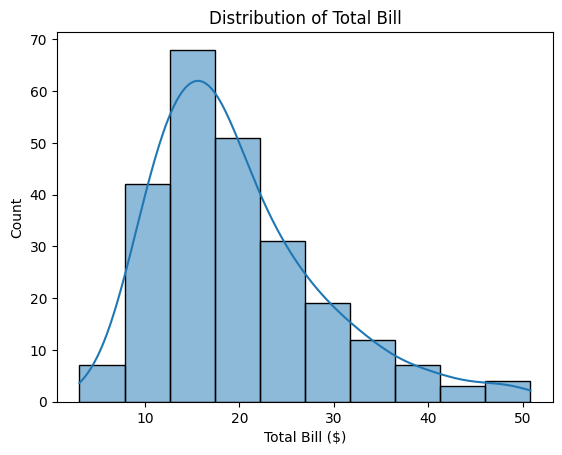

In [14]:
# Distribution of total_bill — helps identify whether bills are concentrated in a specific range
sns.histplot(tips['total_bill'], bins=10, kde=True)
plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill ($)")
plt.ylabel("Count")
plt.show()

In [15]:
# Skewness — a positive value means the data is right-skewed (tail on the right)
print("Skewness of total_bill:", tips['total_bill'].skew())
print("Mean:", tips['total_bill'].mean())
print("Median:", tips['total_bill'].median())

Skewness of total_bill: 1.1332130376158205
Mean: 19.78594262295082
Median: 17.795


## 9. Univariate Analysis — Categorical Variables

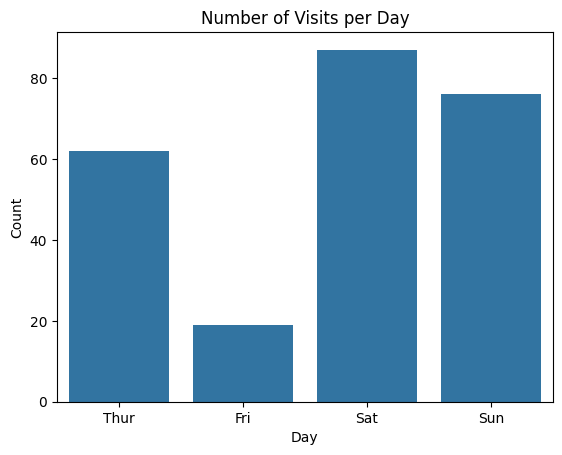

In [16]:
# Visit frequency per day of the week
sns.countplot(x='day', data=tips, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title("Number of Visits per Day")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

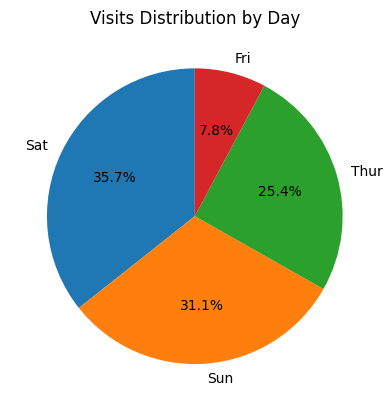

In [17]:
# Proportion of visits per day as a pie chart
plt.pie(
    tips['day'].value_counts(),
    labels=tips['day'].value_counts().index,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Visits Distribution by Day")
plt.show()

## 10. Bivariate Analysis — Numerical vs Numerical

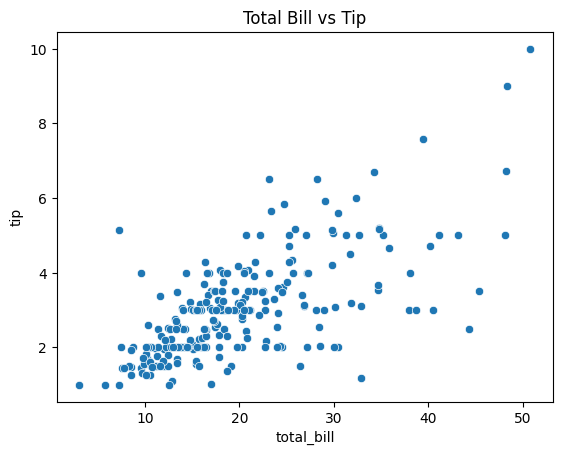

In [18]:
# Does a higher bill lead to a higher tip? (a positive linear relationship is expected)
sns.scatterplot(x='total_bill', y='tip', data=tips)
plt.title("Total Bill vs Tip")
plt.show()

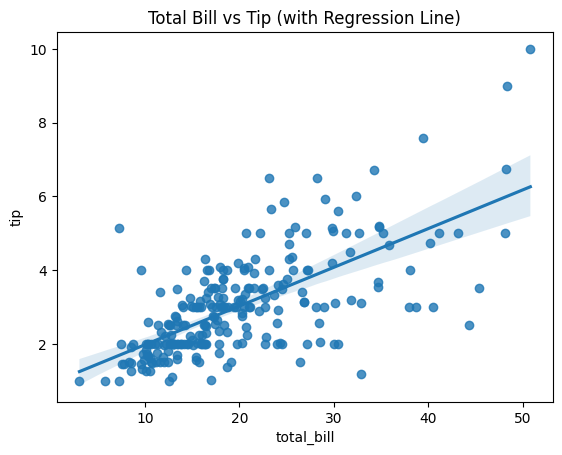

In [19]:
# regplot adds a regression line to visualize the strength of the relationship
sns.regplot(x='total_bill', y='tip', data=tips)
plt.title("Total Bill vs Tip (with Regression Line)")
plt.show()

## 11. Bivariate Analysis — Numerical vs Categorical

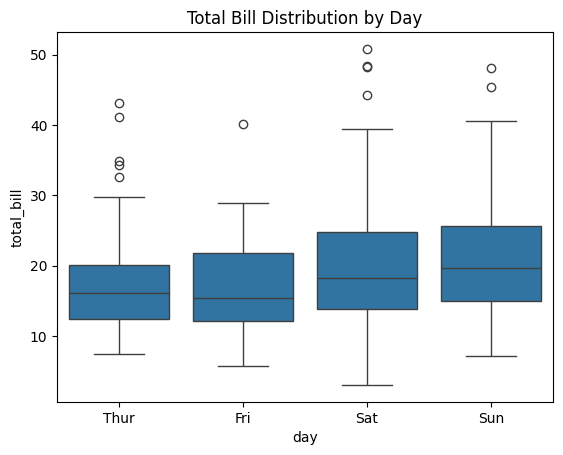

In [20]:
# Bill distribution per day — are customers spending more on certain days?
sns.boxplot(x='day', y='total_bill', data=tips, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title("Total Bill Distribution by Day")
plt.show()

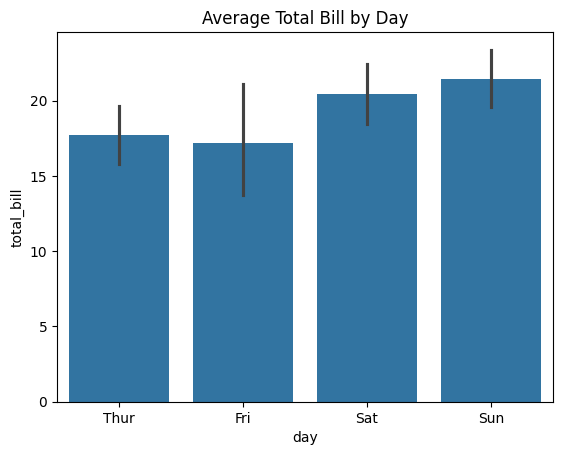

In [21]:
# Average total bill per day
sns.barplot(x='day', y='total_bill', data=tips, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title("Average Total Bill by Day")
plt.show()

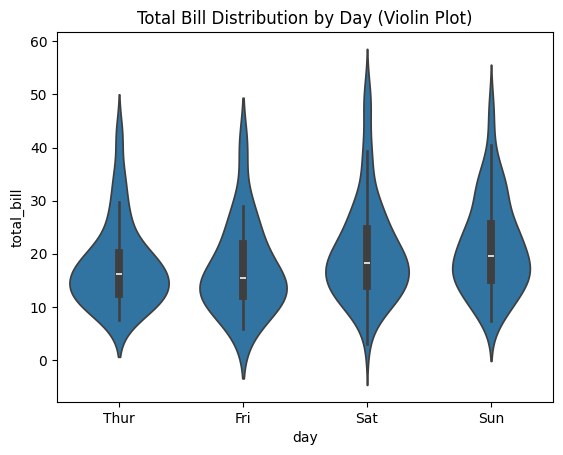

In [22]:
# Violin plot combines a boxplot and KDE — shows both distribution shape and summary stats
sns.violinplot(x='day', y='total_bill', data=tips, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title("Total Bill Distribution by Day (Violin Plot)")
plt.show()

## 12. Bivariate Analysis — Categorical vs Categorical

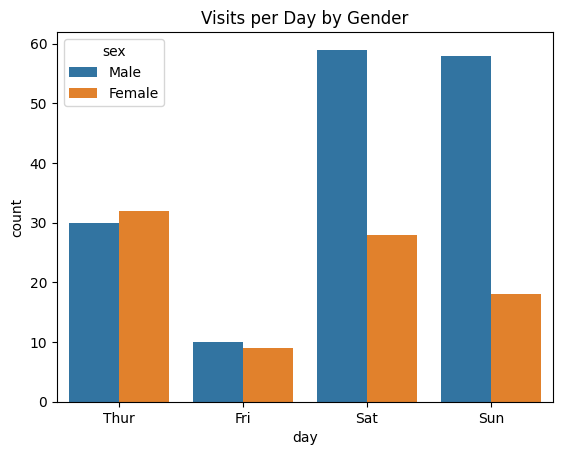

In [23]:
# Do men and women visit equally across all days of the week?
sns.countplot(x='day', hue='sex', data=tips, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title("Visits per Day by Gender")
plt.show()

## 13. Multivariate Analysis

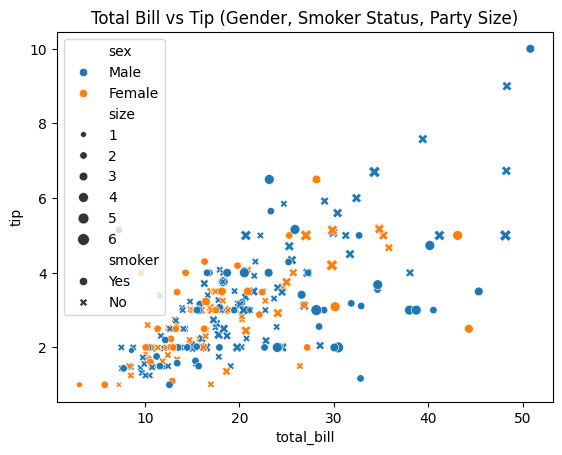

In [24]:
# Each point encodes 4 dimensions: total_bill, tip, sex, smoker status, and party size
sns.scatterplot(
    x='total_bill', y='tip',
    hue='sex', style='smoker', size='size',
    data=tips
)
plt.title("Total Bill vs Tip (Gender, Smoker Status, Party Size)")
plt.show()

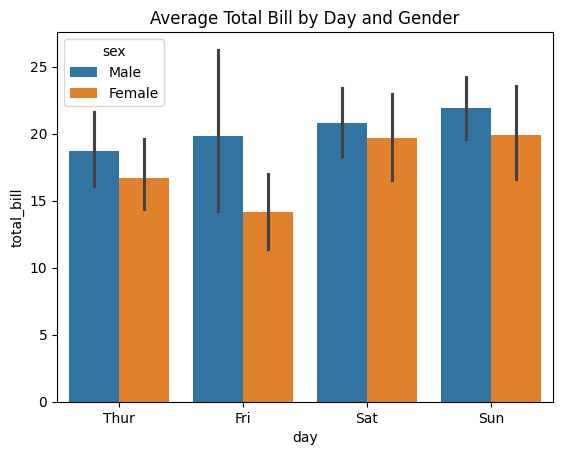

In [25]:
# Average total bill per day, split by gender
sns.barplot(x='day', y='total_bill', hue='sex', data=tips, order=['Thur', 'Fri', 'Sat', 'Sun'])
plt.title("Average Total Bill by Day and Gender")
plt.show()

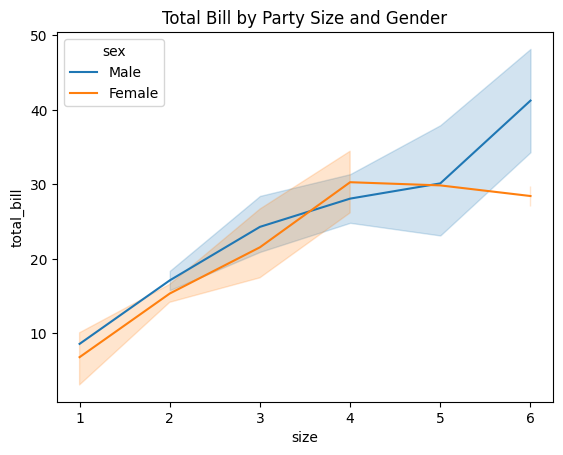

In [26]:
# Does party size affect the bill differently for men vs women?
sns.lineplot(x='size', y='total_bill', hue='sex', data=tips)
plt.title("Total Bill by Party Size and Gender")
plt.show()

## 14. Correlation Analysis

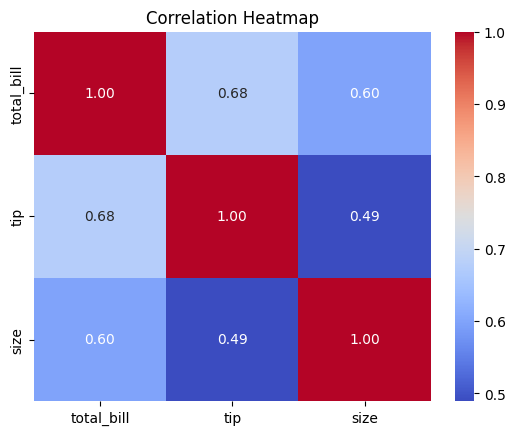

In [27]:
# Heatmap of correlations between numerical variables
# Values close to 1 or -1 indicate a strong relationship
sns.heatmap(tips.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

## 15. Pairplot — Overview of All Relationships

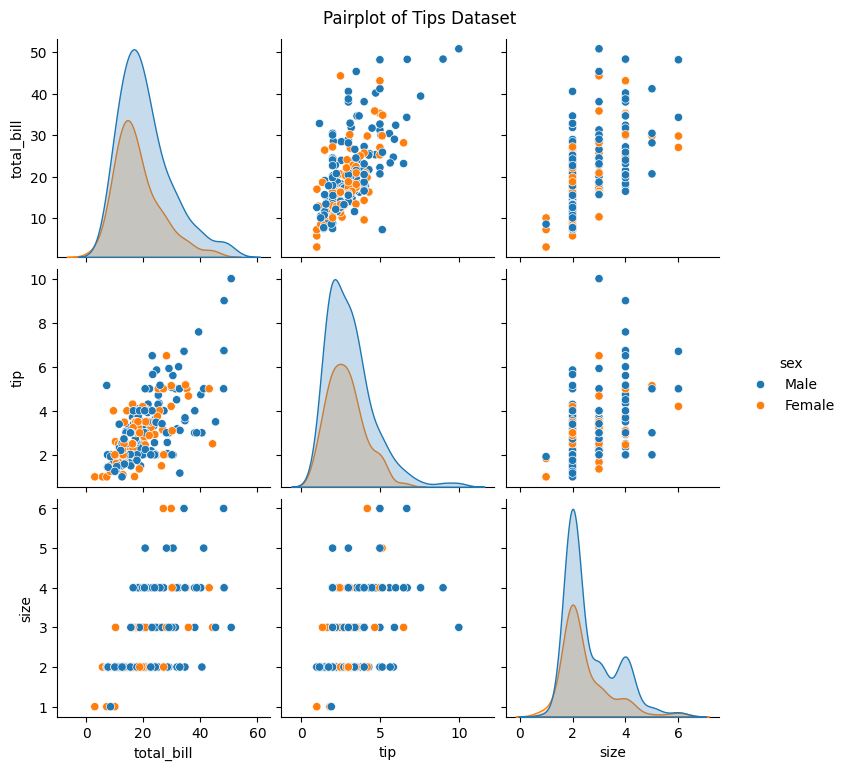

In [28]:
# Pairplot generates scatterplots for every pair of numerical variables at once
# Great for a quick overview of all relationships in the dataset
sns.pairplot(tips, hue='sex')
plt.suptitle("Pairplot of Tips Dataset", y=1.02)
plt.show()

## 16. Key Insights

After analyzing the **tips dataset** containing 244 restaurant records, the following insights were found:

1. **Higher bills correlate with higher tips**  
   There is a clear positive linear relationship between `total_bill` and `tip`. As the bill increases, customers tend to leave larger tips — confirmed by the regression line and correlation heatmap.

2. **Weekends dominate restaurant traffic**  
   Over 65% of visits occur on Saturday and Sunday, suggesting this restaurant is primarily a weekend dining destination rather than a regular weekday spot.

3. **Men tend to pay slightly higher bills**  
   Across most days, male customers show a marginally higher average total bill than female customers, though the difference is not dramatic.

4. **Party size is positively correlated with the total bill**  
   Larger groups naturally result in higher bills. The `size` variable shows a consistent upward trend with `total_bill` regardless of gender.

5. **Total bill is right-skewed**  
   Most customers pay between $10–$25, but a minority pays above $40. This pulls the mean above the median, indicating the presence of high-spending outliers.

6. **Tip percentage decreases as the bill grows**  
   While the absolute tip amount increases with the bill, the tip-to-bill ratio actually decreases for larger bills — meaning high-spending customers tend to tip a lower percentage.
